In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CISC_867/data/Copy Lens_GRN_June_2016_original FOR HACKATHON - Salil Lachke.xlsx')

In [ ]:
df.head()

,S. No,Regulator,Target,New gene symbol for taget,Perturbation,Effect,Stage,Context,Context_2,Measurement,...,Phenotype 2,Phenotype 3,Function,Clinical Relevant Phenotype in Human,Reference,PMID,PMCID,TS of regulator,Unnamed: 24,TS of target
0,417,Acvr1,Apoptosis,Apoptosis,-,o,E9.5,Acvrl-/-,AcvrlCKO/CKO; Le-Cre,TUNEL,...,NaN,NaN,NaN,NaN,"Rajagopal R, Huang J, Dattilo LK, Kaartinen V,...",19733164.0,PMC2783396,1548;TS16 surface ectoderm,NaN,1548;TS16 surface ectoderm
1,414,Acvr1,Proliferation,Proliferation,-,-,E9.5,Acvrl-/-,AcvrlCKO/CKO; Le-Cre,BrdU,...,NaN,NaN,NaN,NaN,"Rajagopal R, Huang J, Dattilo LK, Kaartinen V,...",19733164.0,PMC2783396,1548;TS16 surface ectoderm,NaN,1548;TS16 surface ectoderm
2,1728,Aldh1a1,Aldh1a1,Aldh1a1,-,-,P94,Aldh1a1-/-,Tg(Aldh1a1),Western Blotting,...,NaN,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown
3,1729,Aldh1a1,Aldh3a1,Aldh3a1,-,-,P94,Aldh1a1-/-,Tg(Aldh1a1),Western Blotting,...,NaN,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown
4,1727,"Aldh1a1, Aldh3a1","Aldh1a1, Aldh3a1","Aldh1a1, Aldh3a1",-,-,P274,Aldh1a1-/-/Aldh3al1-/-,"Tg(Aldh1a1,Aldh3al1)",Western Blotting,...,NaN,NaN,NaN,NaN,"Lassen, N., Bateman, J.B., Estey, T., Kuszak, ...",17567582.0,PMC2253645,Unknown,NaN,Unknown


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2726 entries, 0 to 2725
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   S. No                                  2726 non-null   int64  
 1   Regulator                              2726 non-null   object 
 2   Target                                 2726 non-null   object 
 3   New gene symbol for taget              2726 non-null   object 
 4   Perturbation                           2725 non-null   object 
 5   Effect                                 2726 non-null   object 
 6   Stage                                  2725 non-null   object 
 7   Context                                2726 non-null   object 
 8   Context_2                              2720 non-null   object 
 9   Measurement                            2719 non-null   object 
 10  Molecule Analyzed                      2719 non-null   object 
 11  Spec

In [ ]:
import networkx as nx

G = nx.from_pandas_edgelist(
    df,
    source="Regulator",
    target="Target",
    edge_attr=True,
    create_using=nx.DiGraph()
)



Nodes = Total genes in your system

Edges = Total regulatory interactions

In [ ]:
G.number_of_nodes()

812

In [ ]:
G.number_of_edges()

1518

In [ ]:
import numpy as np
np.mean([d for _, d in G.degree()])


np.float64(3.7389162561576357)

In-degree =
How many regulators control this gene?

High in-degree = Highly regulated gene

In [ ]:
np.mean([d for _, d in G.in_degree()])


np.float64(1.8694581280788178)

Out-degree =
How many genes does this regulator control?

High out-degree = Master regulator

In [ ]:
np.mean([d for _, d in G.out_degree()])

np.float64(1.8694581280788178)

Identify Master Regulators

In [ ]:
sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]


[('Zeb2', 209),
 ('Pax6', 127),
 ('Foxe3', 109),
 ('Sparc', 58),
 ('Crebbp, Ep300', 46),
 ('Dicer1', 42),
 ('Mafg, Mafk', 38),
 ('Prox1', 32),
 ('Notch2', 31),
 ('Ilk', 30)]

Identify Highly Regulated Genes

In [ ]:
sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]


[('Proliferation', 46),
 ('Pax6', 45),
 ('Apoptosis', 37),
 ('Cdh1', 31),
 ('Prox1', 29),
 ('Foxe3', 27),
 ('Cryaa', 24),
 ('Sox2', 19),
 ('Ccnd1', 17),
 ('Crygc', 16)]

In [ ]:
nx.degree_centrality(G)


{'Acvr1': 0.002466091245376079,
 'Apoptosis': 0.04562268803945746,
 'Proliferation': 0.05672009864364982,
 'Aldh1a1': 0.004932182490752158,
 'Aldh3a1': 0.006165228113440197,
 'Aldh1a1, Aldh3a1': 0.002466091245376079,
 'Ank2': 0.009864364981504316,
 'alpha-dystroglycan ': 0.002466091245376079,
 'beta-Spectrin': 0.0012330456226880395,
 'CaV1.2': 0.0012330456226880395,
 'Dag1-beta': 0.002466091245376079,
 'MLC': 0.002466091245376079,
 'NrCAM': 0.0012330456226880395,
 'pMLC': 0.002466091245376079,
 'Prx': 0.016029593094944512,
 'Apc': 0.014796547472256474,
 'Acta2': 0.009864364981504316,
 'Ccnd1': 0.02096177558569667,
 'Cdh1': 0.03822441430332922,
 'Col4a4': 0.006165228113440197,
 'Coro1a': 0.011097410604192354,
 'Cryb': 0.016029593094944512,
 'H3f3a': 0.0036991368680641184,
 'laminin': 0.0036991368680641184,
 'Maf': 0.03329223181257707,
 'Pax6': 0.2120838471023428,
 'Apeh': 0.007398273736128237,
 'Cryaa': 0.036991368680641186,
 'Cryab': 0.011097410604192354,
 'Crygd': 0.009864364981504316

Feed Forward Loops

In [ ]:
nx.triads.triadic_census(G)


{'003': 87765453,
 '012': 1064745,
 '102': 13293,
 '021D': 42595,
 '021U': 4442,
 '021C': 7804,
 '111D': 450,
 '111U': 2074,
 '030T': 702,
 '030C': 1,
 '201': 100,
 '120D': 51,
 '120U': 84,
 '120C': 4,
 '210': 22,
 '300': 0}

Feedback loops

In [ ]:
list(nx.strongly_connected_components(G))


[{'Apoptosis'},
 {'Proliferation'},
 {'Acvr1'},
 {'Aldh1a1', 'Aldh3a1'},
 {'Aldh1a1, Aldh3a1'},
 {'alpha-dystroglycan '},
 {'beta-Spectrin'},
 {'CaV1.2'},
 {'Dag1-beta'},
 {'MLC'},
 {'NrCAM'},
 {'pMLC'},
 {'Actb'},
 {'Ahnak'},
 {'AnkB'},
 {'Bfsp1'},
 {'CaV1.3'},
 {'Ezr'},
 {'alpha II- spectrin'},
 {'Atf3'},
 {'Cebpb'},
 {'Chac1'},
 {'Ddit3'},
 {'Dnajb9'},
 {'Herpud1'},
 {'Hspa5'},
 {'Insig1'},
 {'pro-caspase 12'},
 {'Trib3'},
 {'Xbp1'},
 {'Mip'},
 {'Sptbn2'},
 {'Prx'},
 {'Ank2'},
 {'Acta2'},
 {'Ccnd1'},
 {'Cdh1'},
 {'Col4a4'},
 {'Coro1a'},
 {'Cryb'},
 {'H3f3a'},
 {'laminin'},
 {'Bad'},
 {'Ephb2'},
 {'Bcl2'},
 {'Birc5'},
 {'Casp3'},
 {'Igf1r'},
 {'Lamb1'},
 {'Cdkn1b'},
 {'Cryba1'},
 {'Crygc'},
 {'Cdkn1c'},
 {'Cryab'},
 {'Cryba3'},
 {'Crybb1'},
 {'Cryga'},
 {'Crygb'},
 {'Crygd'},
 {'Cryge'},
 {'Crygf'},
 {'E-cadherin'},
 {'Fgfr1'},
 {'AKT'},
 {'Aquaporin 0'},
 {'beta crystallin'},
 {'c-Maf'},
 {'Dlad'},
 {'ERK'},
 {'gamma crystallin'},
 {'pAKT'},
 {'pERK'},
 {'phospho cJun'},
 {'phospho 

Successors = Genes regulated by FOXE3
Predecessors = Genes that regulate CRYAA

visualization example

One regulator and its downstream network.

Instead of messy whole network,
we inspect local regulatory architecture.

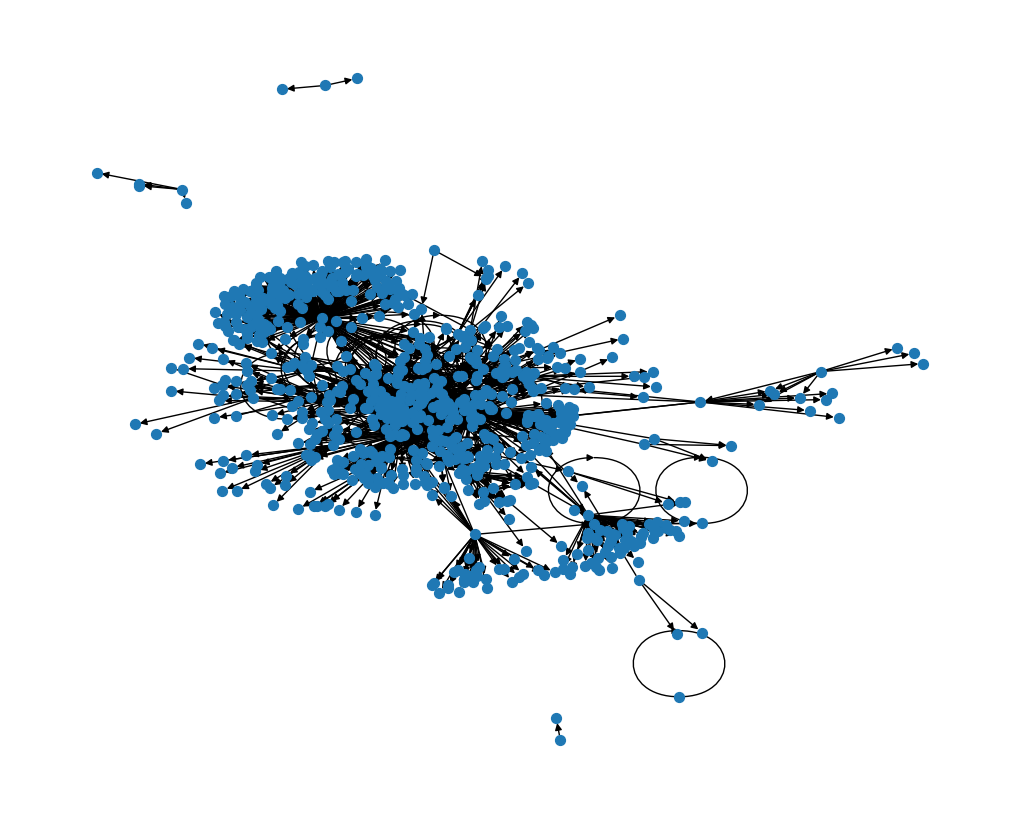

In [ ]:
pos = nx.spring_layout(G, k=0.15)
plt.figure(figsize=(10,8))
nx.draw(G, pos, node_size=50, arrows=True)
plt.show()


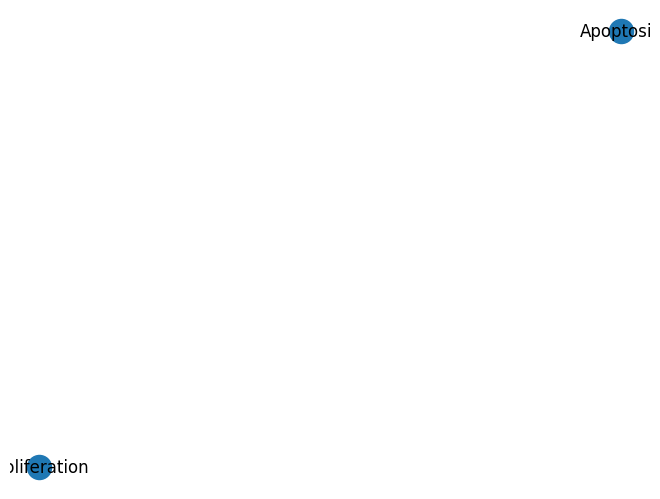

In [ ]:
sub_nodes = list(G.successors("Acvr1"))
subG = G.subgraph(sub_nodes)
nx.draw(subG, with_labels=True)


In [ ]:
keyword = "Acvr1"

mask = df.apply(lambda col: col.astype(str).str.contains(keyword, case=False, na=False))
result = df[mask.any(axis=1)]

print(result)


      S. No      Regulator         Target New gene symbol for taget  \
0       417          Acvr1      Apoptosis                 Apoptosis   
1       414          Acvr1  Proliferation             Proliferation   
88      418         Bmpr1a      Apoptosis                 Apoptosis   
89      415         Bmpr1a  Proliferation             Proliferation   
90      439  Bmpr1a, Acvr1          Acta1                     Acta1   
91      440  Bmpr1a, Acvr1          Acta1                     Acta1   
92      416  Bmpr1a, Acvr1      Apoptosis                 Apoptosis   
93      435  Bmpr1a, Acvr1          Cryaa                     Cryaa   
94      432  Bmpr1a, Acvr1          Foxe3                     Foxe3   
95      438  Bmpr1a, Acvr1   Lens placode              Lens placode   
96      426  Bmpr1a, Acvr1           Pax6                      Pax6   
97      413  Bmpr1a, Acvr1  Proliferation             Proliferation   
98      410  Bmpr1a, Acvr1          Smad1                     Smad1   
99    